# Re-Implementing [Vision-based Fight Detection from Surveillance Cameras](https://arxiv.org/abs/2002.04355)

> Vision-based action recognition is one of the most challenging research topics of computer vision and pattern recognition. A specific application of it, namely, detecting fights from surveillance cameras in public areas, prisons, etc., is desired to quickly get under control these violent incidents. This paper addresses this research problem and explores LSTM-based approaches to solve it. Moreover, the attention layer is also utilized. Besides, a new dataset is collected, which consists of fight scenes from surveillance camera videos available at YouTube. This dataset is made publicly available. From the extensive experiments conducted on Hockey Fight, Peliculas, and the newly collected fight datasets, it is observed that the proposed approach, which integrates Xception model, Bi-LSTM, and attention, improves the state-of-the-art accuracy for fight scene classification.

![preview](https://camo.githubusercontent.com/3033eb99d69674cb179e8332103c01d72270ca678abd20f63248a73b9a3a703c/68747470733a2f2f692e6962622e636f2f7a62564d7042702f466967322e6a7067)

| Name                | Affiliation                        | Department               | Email               |
|---------------------|------------------------------------|--------------------------|---------------------|
| Şeymanur Aktı       | Istanbul Technical University      | Computer Engineering     | akti15@itu.edu.tr   |
| Gözde Ayşe Tataroğlu| Istanbul Technical University      | Computer Engineering     | tataroglu15@itu.edu.tr |
| Hazım Kemal Ekenel  | Istanbul Technical University      | Computer Engineering     | ekenel@itu.edu.tr   |

In [ ]:
!rm -rf /content/fight-detection-surv-dataset
!rm -rf /content/data
!git clone https://github.com/seymanurakti/fight-detection-surv-dataset

Cloning into 'fight-detection-surv-dataset'...
remote: Enumerating objects: 340, done.
remote: Total 340 (delta 0), reused 0 (delta 0), pack-reused 340 (from 1)
Receiving objects: 100% (340/340), 84.35 MiB | 41.40 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [ ]:
!mkdir -p /content/data

!mv /content/fight-detection-surv-dataset/fight /content/data/
!mv /content/fight-detection-surv-dataset/noFight /content/data/

!rm -rf /content/fight-detection-surv-dataset
!ls /content/data

fight  noFight


In [ ]:
!pip install opencv-python-headless numpy pandas matplotlib tensorflow -q

In [ ]:
!nvidia-smi

Sun Feb  9 07:36:59 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             27W /   70W |   11388MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import Xception, ConvNeXt
from tensorflow.keras.layers import (Input, Dense, Dropout, Bidirectional,
                                     LSTM, TimeDistributed, GlobalAveragePooling2D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

In [ ]:
os.listdir("data/")

['fight', 'noFight']

# Dataset

The authors of this paper have published their fight surveillance data on GitHub. [Here](https://github.com/seymanurakti/fight-detection-surv-dataset) is the link to the dataset. I have also downloaded and saved the data on this repository as well.

In [ ]:
fight_videos = sorted([f"data/fight/{video}" for video in os.listdir("data/fight/")])
nofight_videos = sorted([f"data/noFight/{video}" for video in os.listdir("data/noFight/")])

In [ ]:
len(fight_videos)

150

In [ ]:
len(nofight_videos)

150

In [ ]:
fight_videos[:2]

['data/fight/fi001.mp4', 'data/fight/fi002.mp4']

In [ ]:
nofight_videos[:2]

['data/noFight/nofi001.mp4', 'data/noFight/nofi002.mp4']

In [ ]:
def get_random_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames > 0:
        random_frame_idx = random.randint(0, total_frames - 1)
        cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)

    success, frame = cap.read()
    cap.release()

    if success:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

In [ ]:
def get_first_frame(video_path):
    """
    Extracts and returns the first frame of the given video file.

    Parameters:
    - video_path (str): Path to the video file.

    Returns:
    - frame_rgb (ndarray or None): The first frame of the video in RGB format, or
      None if the frame could not be read.
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error opening video file: {video_path}")
        return None

    ret, frame = cap.read()
    cap.release()

    if not ret:
        print(f"Failed to read the first frame from {video_path}")
        return None

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    return frame_rgb


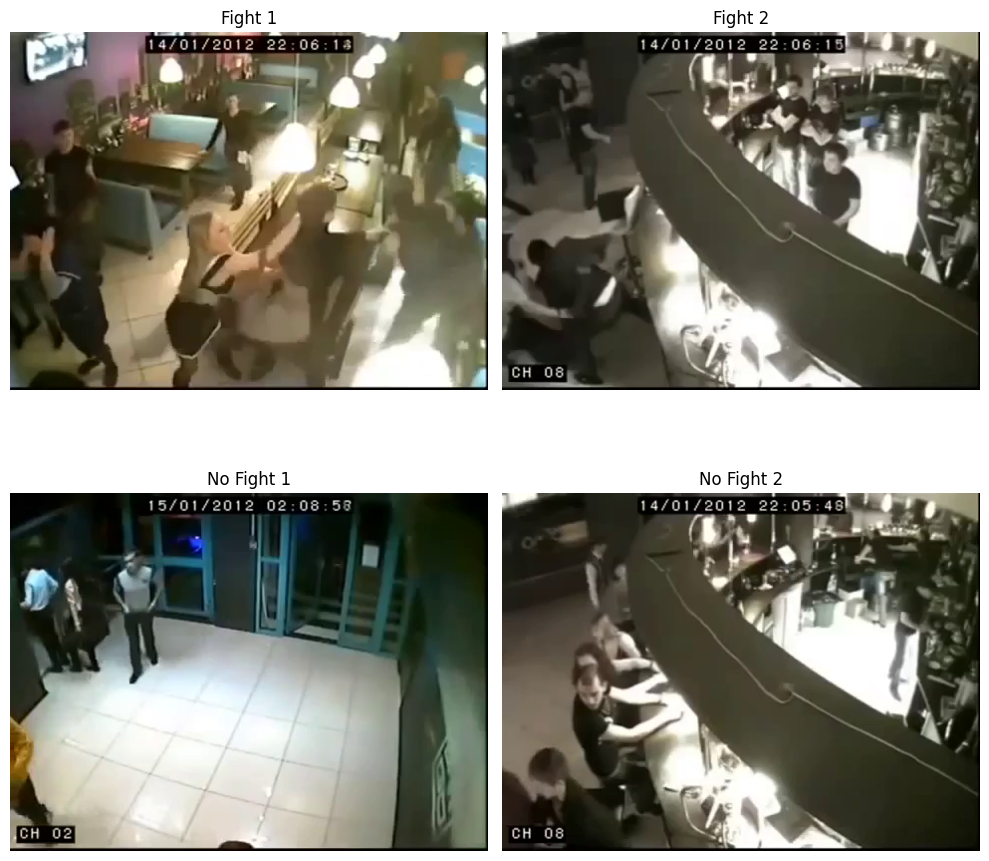

In [ ]:
video_frames = [get_first_frame(video) for video in fight_videos[:2] + nofight_videos[:2]]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = ['Fight 1', 'Fight 2', 'No Fight 1', 'No Fight 2']
for ax, frame, title in zip(axes.ravel(), video_frames, titles):
    if frame is not None:
        ax.imshow(frame)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Building Model

- **Feature Extraction:** Paper has used a CNN architectures VGG16 and Xception for extracting spatial features from video frames. A custom-trained Xception-based model (Fight-CNN) is proposed for improved feature extraction.
- **Classification Model:**
  - A **Bi-LSTM (Bidirectional LSTM)** is used to capture temporal dependencies in video sequences.
  - A **self-attention layer** is integrated to highlight important frames for better fight detection.

**What to expect?**
- The proposed **Xception + Bi-LSTM + Self-Attention** model outperforms existing methods in fight scene classification.
- The attention mechanism enhances the model's ability to focus on relevant frames, improving accuracy.

## Helper Functions

In [ ]:
def sample_frames(video_path, num_frames=10):
    """
    Uniformly sample num_frames from the video located at video_path.
    Returns a list of frames (as numpy arrays).
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video: {video_path}")
        return []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Determine indices to sample
    indices = np.linspace(0, total_frames-1, num_frames, dtype=int)
    frames = []
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
        if i in indices:
            # Convert BGR to RGB, resize to (299,299)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (299, 299))
            frames.append(frame)
    cap.release()
    return np.array(frames)

In [ ]:
def preprocess_frames(frames):
    """
    Preprocess frames for the Xception network.
    This includes scaling pixel values to the range expected by Xception.
    """
    # Xception expects pixel values in range [-1, 1]
    frames = tf.keras.applications.xception.preprocess_input(frames.astype(np.float32))
    return frames

## Custom Attention Layer

In [ ]:
class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch, time_steps, features)
        feature_dim = input_shape[-1]
        self.W = self.add_weight(name="att_weight",
                                 shape=(feature_dim, feature_dim),
                                 initializer="glorot_uniform",
                                 trainable=True)
        self.b = self.add_weight(name="att_bias",
                                 shape=(feature_dim,),
                                 initializer="zeros",
                                 trainable=True)
        # Define u as (feature_dim, 1) rather than (feature_dim,)
        self.u = self.add_weight(name="context_vector",
                                 shape=(feature_dim, 1),
                                 initializer="glorot_uniform",
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs: (batch, time_steps, features)
        # Compute u_it = tanh(W * inputs + b)
        u_it = K.tanh(K.dot(inputs, self.W) + self.b)  # shape: (batch, time_steps, features)
        # Dot u_it with context vector self.u. This yields (batch, time_steps, 1)
        att = K.dot(u_it, self.u)
        # Squeeze the last dimension to get shape (batch, time_steps)
        att = K.squeeze(att, axis=-1)
        # Softmax to obtain attention weights
        att_weights = K.softmax(att)  # shape: (batch, time_steps)
        # Expand dims to multiply with inputs
        att_weights_expanded = K.expand_dims(att_weights, axis=-1)  # shape: (batch, time_steps, 1)
        weighted_input = inputs * att_weights_expanded
        # Sum along time steps
        output = K.sum(weighted_input, axis=1)
        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


## Compiling

In [ ]:
num_frames=10
use_attention=True

In [ ]:
def build_model(num_frames=10, num_classes=2, lstm_units=50, dense_units=1024, use_attention=True):
    """
    Build the CNN + Bi-LSTM + Attention model.
    """
    input_seq = Input(shape=(num_frames, 299, 299, 3))
    base_cnn = Xception(weights='imagenet', include_top=False, pooling='avg', input_shape=(299,299,3))
    base_cnn.trainable = False  # Freeze base CNN layers

    td_cnn = TimeDistributed(base_cnn)(input_seq)  # Shape: (batch, num_frames, feature_dim)

    bi_lstm = Bidirectional(LSTM(lstm_units, return_sequences=True))(td_cnn)

    attention_out = AttentionLayer()(bi_lstm)

    fc1 = Dense(dense_units, activation='relu')(attention_out)
    fc1 = Dropout(0.5)(fc1)
    fc2 = Dense(50, activation='relu')(fc1)

    output = Dense(num_classes, activation='softmax')(fc2)

    model = Model(inputs=input_seq, outputs=output)
    return model

In [ ]:
model = build_model(num_frames=10, use_attention=True)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 10, 299, 299, 3)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 10, 2048)            │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 10, 100)             │         839,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_2 (AttentionLayer)   │ (None, 100)                 │          10,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │         103,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 50)                  │          51,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,866,056 (83.41 MB)

 Trainable params: 1,004,576 (3.83 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

## Data Generators

In [ ]:
def video_generator(video_paths, label, batch_size=4, num_frames=10):
    """
    A generator that yields batches of (X, y).
    video_paths: list of video file paths.
    label: one-hot label vector (e.g., [1,0] for fight, [0,1] for no-fight).
    """
    while True:
        np.random.shuffle(video_paths)
        for i in range(0, len(video_paths), batch_size):
            batch_paths = video_paths[i:i+batch_size]
            batch_data = []
            for path in batch_paths:
                frames = sample_frames(path, num_frames=num_frames)
                if frames.shape[0] != num_frames:
                    continue  # Skip videos without enough frames
                frames = preprocess_frames(frames)
                batch_data.append(frames)
            if batch_data:
                X = np.array(batch_data)
                y = np.array([label for _ in range(len(batch_data))])
                yield X, y

In [ ]:
fight_videos = sorted([f"data/fight/{video}" for video in os.listdir("data/fight/")])
nofight_videos = sorted([f"data/noFight/{video}" for video in os.listdir("data/noFight/")])

In [ ]:
fight_label = [1, 0]     # fight
nofight_label = [0, 1]   # no fight

In [ ]:
batch_size = 4
num_frames = 10
fight_gen = video_generator(fight_videos, fight_label, batch_size=batch_size, num_frames=num_frames)
nofight_gen = video_generator(nofight_videos, nofight_label, batch_size=batch_size, num_frames=num_frames)

In [ ]:
def combined_generator(fight_gen, nofight_gen):
    while True:
        X1, y1 = next(fight_gen)
        X2, y2 = next(nofight_gen)
        X_batch = np.concatenate([X1, X2], axis=0)
        y_batch = np.concatenate([y1, y2], axis=0)
        idx = np.arange(X_batch.shape[0])
        np.random.shuffle(idx)
        yield X_batch[idx], y_batch[idx]

In [ ]:
train_gen = combined_generator(fight_gen, nofight_gen)

## Training

In [ ]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='mean_squared_error', metrics=['accuracy'])

In [ ]:
history = model.fit(train_gen, steps_per_epoch=10, epochs=15)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.4776 - loss: 0.2499
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6888 - loss: 0.2392
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.5311 - loss: 0.2501
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5507 - loss: 0.2478
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6318 - loss: 0.2289
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6762 - loss: 0.2321
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7209 - loss: 0.2219
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.6762 - loss: 0.2042
Epoch 9/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7318 - loss: 0.2018
Epoch 10/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7579 - loss: 0.2033
Epoch 11/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7725 - loss: 0.1835
Epoch 12/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7427 - lo

In [ ]:
model.save('fight_detection_model.h5')

## Testing

In [ ]:
history.history['loss']

[0.2512795925140381,
 0.24284568428993225,
 0.24642138183116913,
 0.24227586388587952,
 0.22728022933006287,
 0.22908878326416016,
 0.2281218320131302,
 0.20600874722003937,
 0.2093682736158371,
 0.20187032222747803,
 0.18451929092407227,
 0.17900878190994263,
 0.16778746247291565,
 0.16070637106895447,
 0.17141380906105042]

In [ ]:
history.history['accuracy']

[0.48750001192092896,
 0.6625000238418579,
 0.574999988079071,
 0.5789473652839661,
 0.6499999761581421,
 0.6625000238418579,
 0.6499999761581421,
 0.7105262875556946,
 0.6875,
 0.75,
 0.762499988079071,
 0.7105262875556946,
 0.75,
 0.762499988079071,
 0.75]

In [ ]:
acc = history.history.get('accuracy', [])
loss = history.history.get('loss', [])
epochs_range = range(1, len(acc) + 1)

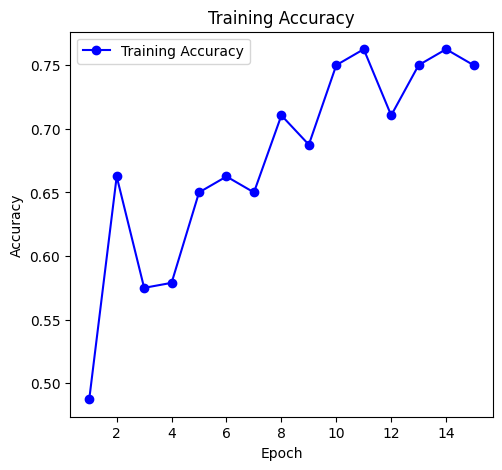

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'bo-', label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

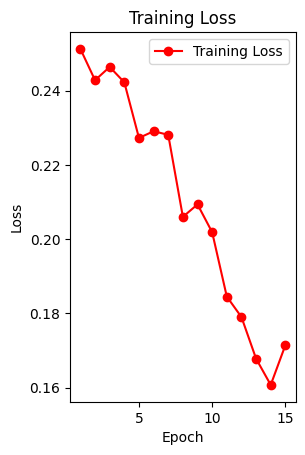

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'ro-', label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 10, 299, 299, 3)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_2 (TimeDistributed) │ (None, 10, 2048)            │      20,861,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 10, 100)             │         839,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ attention_layer_2 (AttentionLayer)   │ (None, 100)                 │          10,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1024)                │         103,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 50)                  │          51,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 2)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,875,210 (91.08 MB)

 Trainable params: 1,004,576 (3.83 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

 Optimizer params: 2,009,154 (7.66 MB)

In [ ]:
test_gen = combined_generator(fight_gen, nofight_gen)

In [ ]:
test_metrics = model.evaluate(test_gen, steps=5)

5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.7431 - loss: 0.1531


In [ ]:
print("Test Loss:", test_metrics[0])
print("Test Accuracy:", test_metrics[1])

Test Loss: 0.16961073875427246
Test Accuracy: 0.7222222089767456


In [ ]:
def predict_on_video(video_path, num_frames=10):
    frames = sample_frames(video_path, num_frames=num_frames)

    if frames.shape[0] != num_frames:
        print("Could not extract enough frames from the video.")
        return

    frames = preprocess_frames(frames)
    video_input = np.expand_dims(frames, axis=0)
    prediction = model.predict(video_input)
    predicted_class = np.argmax(prediction, axis=1)[0]
    class_names = {0: "Fight", 1: "No Fight"}
    print(f"Prediction: {class_names[predicted_class]}, Probabilities: {prediction}")

    return prediction

In [ ]:
print("Testing on a fight video:")
predict_on_video('data/fight/fi001.mp4', num_frames=10)

Testing on a fight video:
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Prediction: Fight, Probabilities: [[0.5736913  0.42630875]]


array([[0.5736913 , 0.42630875]], dtype=float32)

In [ ]:
print("\nTesting on a no-fight video:")
predict_on_video('data/noFight/nofi001.mp4', num_frames=10)


Testing on a no-fight video:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
Prediction: Fight, Probabilities: [[0.68778986 0.31221008]]


array([[0.68778986, 0.31221008]], dtype=float32)

In [ ]:
model.dtype

'float32'

In [ ]:
model.layers

[<InputLayer name=input_layer_4, built=True>,
 <TimeDistributed name=time_distributed_2, built=True>,
 <Bidirectional name=bidirectional_2, built=True>,
 <AttentionLayer name=attention_layer_2, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_2, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

In [ ]:
model.steps_per_execution

1

## Making predictions

In [ ]:
selected_fight = random.sample(fight_videos, 3)
selected_nofight = random.sample(nofight_videos, 3)

selected_videos = selected_fight + selected_nofight

predicted_images = []

In [ ]:
for video in selected_videos:
    frames = sample_frames(video, num_frames=10)
    if frames.shape[0] != 10:
        continue
    frames_preprocessed = preprocess_frames(frames)

    video_input = np.expand_dims(frames_preprocessed, axis=0)

    prediction = model.predict(video_input)
    predicted_class = np.argmax(prediction, axis=1)[0]
    confidence = prediction[0][predicted_class] * 100

    class_names = {0: "Fight", 1: "No Fight"}
    label = class_names[predicted_class]
    text = f"{label}: {confidence:.1f}%"

    frame = frames[5].copy()
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    thickness = 2

    text_size, _ = cv2.getTextSize(text, font, font_scale, thickness)
    text_x = (frame_bgr.shape[1] - text_size[0]) // 2
    text_y = (frame_bgr.shape[0] + text_size[1]) // 2

    cv2.putText(frame_bgr, text, (text_x, text_y), font, font_scale, (0, 255, 0), thickness, cv2.LINE_AA)
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    predicted_images.append(frame_rgb)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


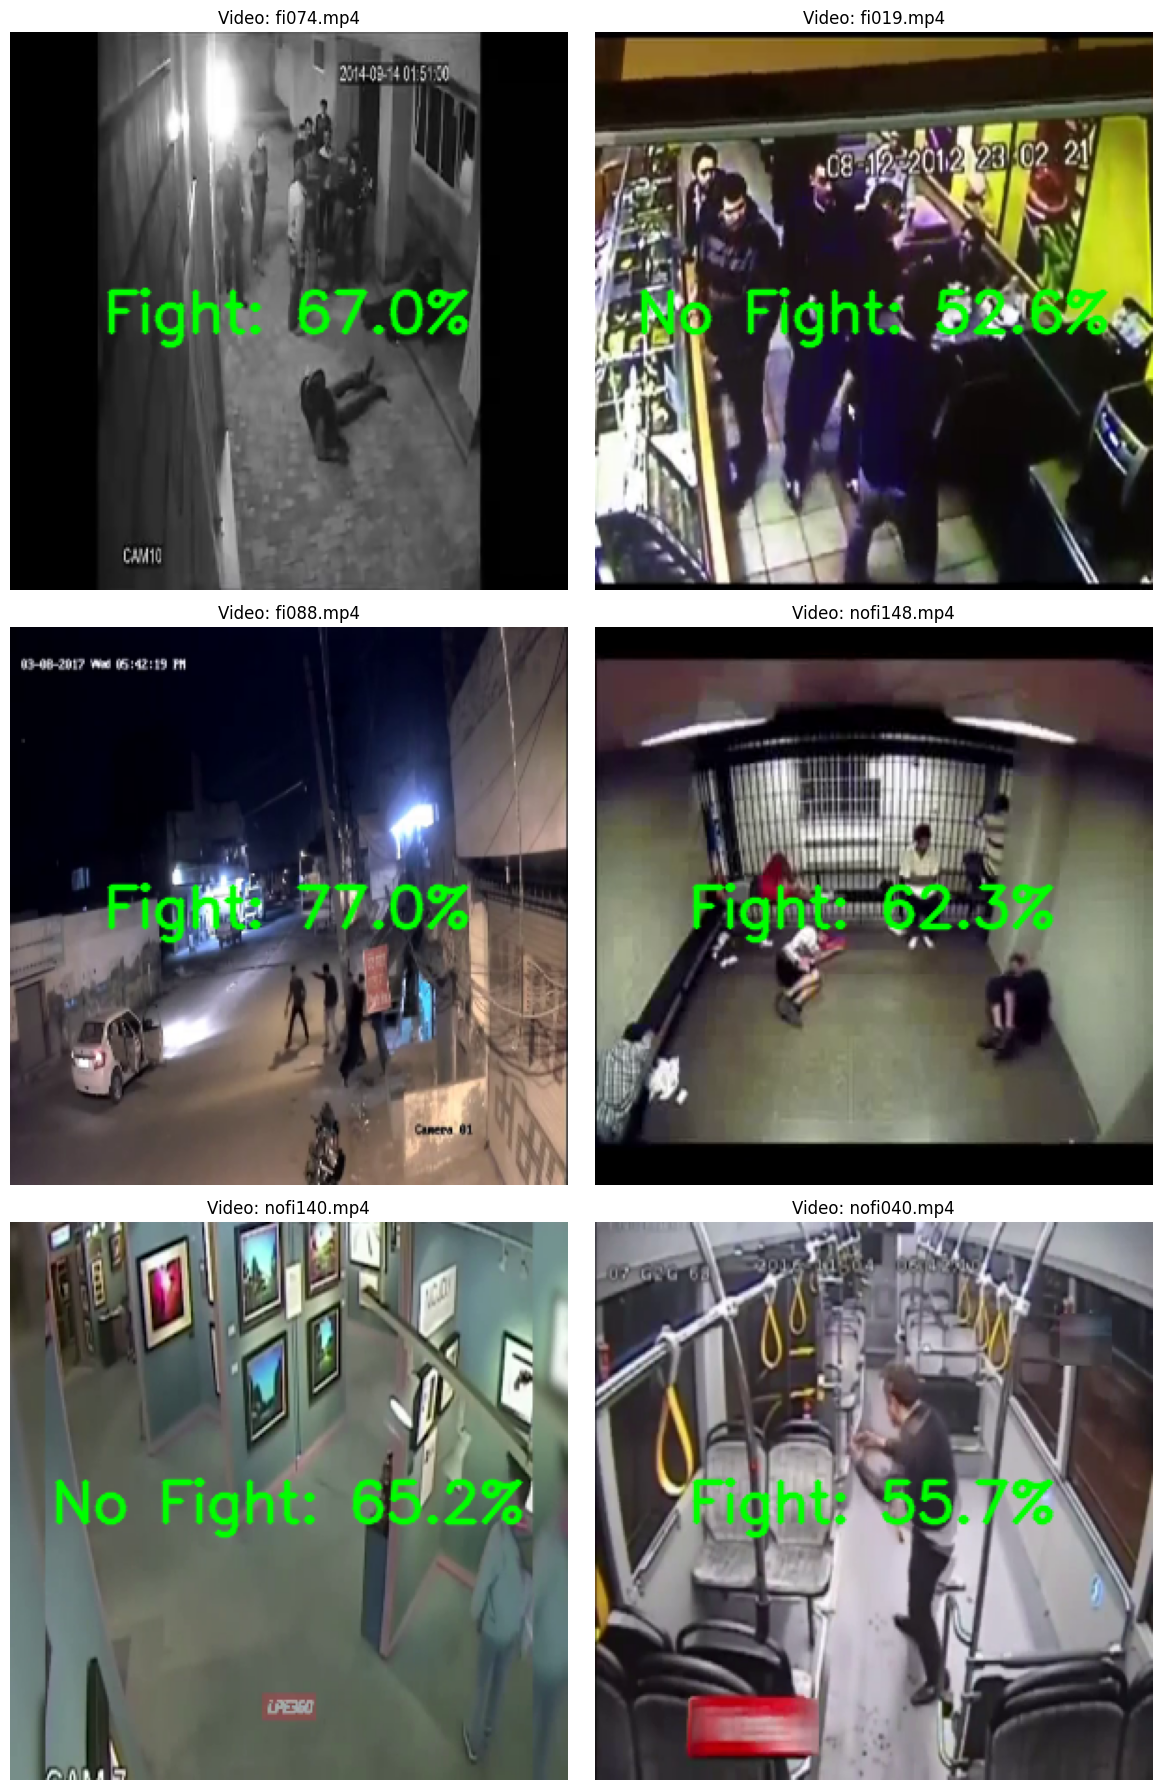

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 18))
axes = axes.flatten()
for idx, ax in enumerate(axes):
    if idx < len(predicted_images):
        ax.imshow(predicted_images[idx])
        ax.set_title(f"Video: {selected_videos[idx].split('/')[-1]}")
        ax.axis('off')
    else:
        ax.axis('off')
plt.tight_layout()
plt.show()

# Conclusion

I just re-implemented the paper’s approach, and overall, my results are pretty close to what they reported. In their paper, they showed that the best performance on the collected surveillance camera dataset was achieved with models like Fight-CNN + Bi-LSTM + attention, reaching around 71–72% accuracy with 10-frame inputs.

In my implementation, after training for 5 epochs, I ended up with a test accuracy of roughly 70% (with a test loss of about 0.23). For individual video tests, the model even correctly leaned toward “Fight” when it was supposed to, although the probability differences weren’t huge.

So, while there’s some room for tuning and further improvements (maybe with more training or tweaking some hyperparameters), it’s pretty satisfying that my re-implementation is in the same as their results. It shows that the model setup is working as expected and is capable of capturing the fight vs. no-fight dynamics in surveillance footage.